### 목표설정
- 선형회귀모델을 활용해서 보스턴 주택가격을 예측해봅시다.
- 특성 확장을 해서 성능을 개선시켜 봅시다.
- 규제 모델을 활용해봅시다.

In [92]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [93]:
# 데이터 불러오기
data = pd.read_csv('./data/house_price.csv')
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,CAT.MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,1
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,1
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,0
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,0
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,0
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,0


In [94]:
# 결측치 확인하기
data.info()

# -> 결측치 없음
# -> 컬럼 정보 확인 필요

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CRIM      506 non-null    float64
 1   ZN        506 non-null    float64
 2   INDUS     506 non-null    float64
 3   CHAS      506 non-null    int64  
 4   NOX       506 non-null    float64
 5   RM        506 non-null    float64
 6   AGE       506 non-null    float64
 7   DIS       506 non-null    float64
 8   RAD       506 non-null    int64  
 9   TAX       506 non-null    int64  
 10  PTRATIO   506 non-null    float64
 11  B         506 non-null    float64
 12  LSTAT     506 non-null    float64
 13  MEDV      506 non-null    float64
 14  CAT.MEDV  506 non-null    int64  
dtypes: float64(11), int64(4)
memory usage: 59.4 KB


In [95]:
# 컬럼 추출하기
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV', 'CAT.MEDV'],
      dtype='object')

**[독립변수 / 특성값 / 문제데이터]**
- 'CRIM' : 구역별 1인당 범죄율 - 범죄율이 높으면 집값이 낮아지는 경향
- 'ZN' : 25,000 평방피트를 초과하는 거주지역의 비율 - 대형 주택단지 비중
- 'INDUS' : 구역별 비소매 상업지역 점유 비율 - 공업/상업 시설 밀집도 (주변 인프라)
- 'CHAS' : 찰스강과 인접해있는지(0 - 인접X / 1 - 인접) - 조망권/입지 가치
- 'NOX' : 대기 중 일산화질소 농도 - 환경 오염 정도
- 'RM' : 주택 1가구당 평균 방의 갯수
- 'AGE' : 1940년 이전 건축된 소유주택의 비율 - 건물의 노후도
- 'DIS' : 보스턴 직업센터까지의 가중 거리 - 도심 접근성
- 'RAD' : 방사형 고속도로 접근성 지수 - 교통 편의성
- 'TAX' : 10,000달러 당 재산세의 비율 - 세금 부담 정도
- 'PTRATIO' : 구역별 학생-교사 비율 - 교육환경(낮을수록 학급당 학생수 적다)
- 'B' : 흑인의 비율 - 치안
- 'LSTAT' : 하위계층의 비율 - 소득,직업,교육수준 ... 

**[종속변수 / 예측값 / 정답데이터]**
- 'MEDV' : 본인 소유 주택가격의 중앙값(단위는 $1000)
- 'CAT.MEDV' : 30,000달러 이상이면 1 / 미만이면 0 -> 필요없는 컬럼(우리는 회귀분석 진행)
  -> 삭제예정

In [96]:
# CAT.MEDV 컬럼 삭제
data = data.drop('CAT.MEDV', axis = 1)
data

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [97]:
# 기술 통계 살펴보기

# count - 데이터 갯수
# mean - 평균
# std - 표준편차
# min - 최솟값
# 50% - 중위값(중앙값)
# max - 최댓값
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


**[4분위수]**
- 전체 데이터를 4등분 해준다.
- 25% 1사분위 / 50% 2사분위&중앙값 / 75% 3사분위 / 100% 4사분위
- 데이터의 분포를 확인 할 때 사용 / 이상치 탐색시 사용 
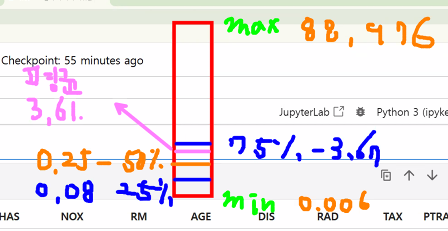
- 범죄율(CRIM)에 대한 데이터는 모든 값이 최솟값에 쏠려 있다. <br>-> 범죄율이 낮은 쪽으로 몰려있다.

In [98]:
# 상관계수 살펴보기
# 상관계수 : 두 변수 사이에 관계가 얼마나 되는지 강도와 뱡향을 수치화 한 지표
# 범위 : -1 ~ 1

# 상관계수 (피어슨 상관계수)
# 0.7 ~ 1.0 : 강한 상관관계
# 0.3 ~ 0.7 : 뚜렷한 상관관계
# 0.1 ~ 0.3 : 약한 상관관계
# 0.0 ~ 0.1 : 관계거의 없음
# + : 양의 상관관계, 하나의 변수가 증가하면 다른 변수도 일정한 비율로 증가
# - : 음의 상관관계, 하나의 변수가 증가하면 다른 변수도 일정한 비율로 감소

data.corr()
# 인덱스와 컬럼의 이름과 순서가 동일 
# 대각선 값이 1인것은 볼 필요 없음

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


In [99]:
# 1. 상관계수를 보고싶은 컬럼을 추출하기
data.corr()['CRIM']

CRIM       1.000000
ZN        -0.200469
INDUS      0.406583
CHAS      -0.055892
NOX        0.420972
RM        -0.219247
AGE        0.352734
DIS       -0.379670
RAD        0.625505
TAX        0.582764
PTRATIO    0.289946
B         -0.385064
LSTAT      0.455621
MEDV      -0.388305
Name: CRIM, dtype: float64

In [100]:
# 2. 상관계수의 절대값을 확인하기
data.corr()['CRIM'].abs()

CRIM       1.000000
ZN         0.200469
INDUS      0.406583
CHAS       0.055892
NOX        0.420972
RM         0.219247
AGE        0.352734
DIS        0.379670
RAD        0.625505
TAX        0.582764
PTRATIO    0.289946
B          0.385064
LSTAT      0.455621
MEDV       0.388305
Name: CRIM, dtype: float64

In [101]:
# 3. 내림차순 정렬진행
data.corr()['CRIM'].abs().sort_values(ascending = False)
# 'RAD'컬럼이 상관계수 가장 크다.

CRIM       1.000000
RAD        0.625505
TAX        0.582764
LSTAT      0.455621
NOX        0.420972
INDUS      0.406583
MEDV       0.388305
B          0.385064
DIS        0.379670
AGE        0.352734
PTRATIO    0.289946
RM         0.219247
ZN         0.200469
CHAS       0.055892
Name: CRIM, dtype: float64

In [21]:
# 4. 기호판별하기
# 양의 상관관계 - CRIM이 증가하면 일정 비율로 RAD도 증가하는 관계다.

<Axes: >

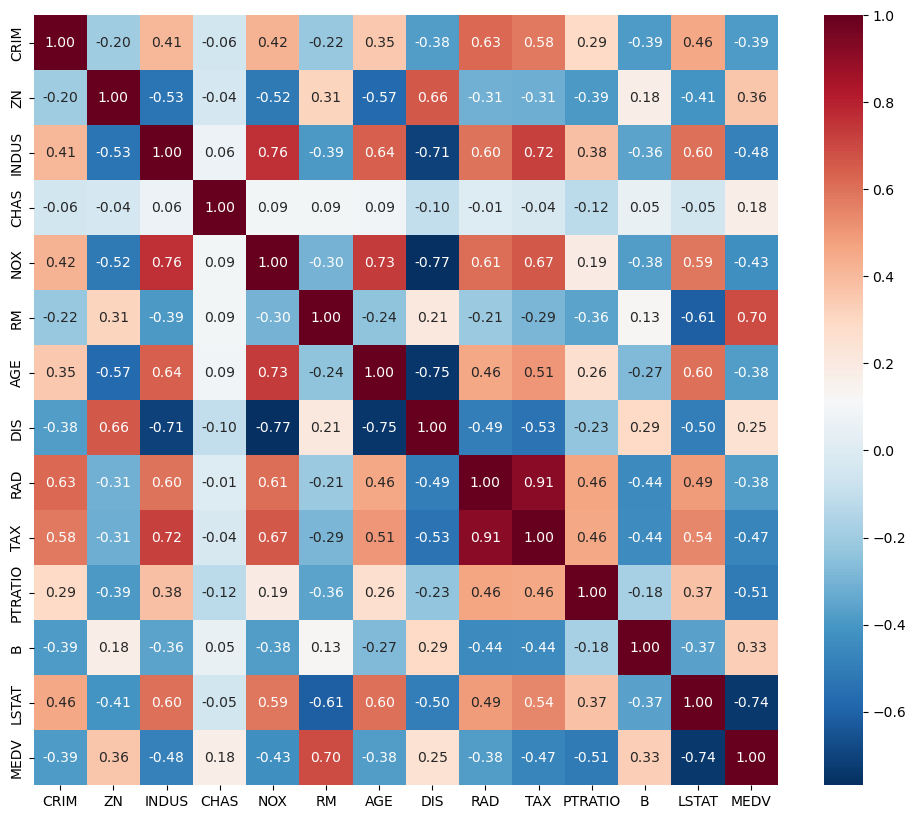

In [102]:
# 5. 시각화 진행하기
import seaborn as sns
plt.figure(figsize = (12,10)) # 그래프 사이즈 조절

sns.heatmap(
    data.corr(), # 히트맵을 그릴 데이터프레임
    annot = True, # 히트맵 내부 수치값 표시
    fmt = ".2f", # 소수점 자리 지정
    cmap = 'RdBu_r' # 양수 - 빨간색 / 음수 - 파란색, _r은 reverse의 약자
)

In [ ]:
# 히트맵으로 시각화 하는 이유
# 색깔의 진하기에 따라 약한 상관관계인지 강한 상관관계인지 파악
# 색깔로 양의 상관관계 / 음의 상관관계 파악

### 20260305
- 데이터분할 -> 모델학습 -> 평가 -> 특성확장 -> 규제모델

In [103]:
# 데이터 분할
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [104]:
X = data.drop('MEDV', axis=1)
y = data['MEDV']

In [105]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [106]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [107]:
X.shape, y.shape

((506, 13), (506,))

In [108]:
# 모델 불러오기
from sklearn.linear_model import LinearRegression

In [109]:
linear_model = LinearRegression()

In [110]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 11,
                                                    test_size = 0.3)

In [111]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

In [24]:
# 모델 학습
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
# 교차 검증
from sklearn.model_selection import cross_val_score

In [27]:
rs = cross_val_score(linear_model, X_train, y_train, cv=5)
print(rs)
print(rs.mean()) # r2_score / 결정계수

[0.76792022 0.79813154 0.5396779  0.49979667 0.76997136]
0.6750995382081543


In [29]:
# 선형회귀 평가지표 사용해보기
# 평가지표를 사용하기 위해서는 예측값이 필요하다.
pred = linear_model.predict(X_test)
pred

array([23.84511817,  2.88426841, 27.76633861, 26.04249007,  6.76316313,
       15.35541663, 23.56500079,  4.90218715, 40.73094074, 30.08405102,
       10.49820545, 17.53870021, 25.79296314, 23.41327065, 19.18044314,
        7.46239972, 35.91178934, 30.93404371, 22.32918975, 13.50668882,
       26.55733115, 34.02181675, 43.6563234 , 33.44813081, 13.07511303,
       12.50832552, 15.92047244, 19.18436321, 31.68869889, 25.04033235,
       12.53125467, 11.73831064, 20.05702853, 16.48196613, 24.69407984,
       23.13757738, 26.49138905, 19.73388257, 20.61196586, 35.04976003,
       23.52204105, 31.01418097, 26.95232052, 13.20403704, 27.51568394,
       20.47648818, 21.5362907 , 26.40141089, 20.01322823, 18.62521146,
       23.67383693, 38.26213637, 26.19999601, 29.54287364, 38.76919964,
       31.38330385, 33.21749275, 17.29934134, 19.97054504, 17.58043181,
       24.43965061, 22.1907987 , 11.81570295, 19.87708088, 22.20317672,
        7.58585511, 13.86474148, 14.54904038, 30.15872227, 40.98

In [30]:
# 선형회귀 평가도구 가져오기
from sklearn.metrics import mean_squared_error as mse # 평균제곱오차
from sklearn.metrics import mean_absolute_error as mae # 평균절대오차
from sklearn.metrics import r2_score # R2_score(결정계수)

In [31]:
# mse 살펴보기
mse(y_test, pred)
# 1000달러 기준으로 살펴보기 때문에 1000을 곱해주자
# 25014달러 오차

25.014130701654267

In [34]:
# rmse 살펴보기
np.sqrt(mse(y_test, pred))
# 1000달러 기준으로 살펴보기 때문에 1000을 곱해주자
# 25014달러 오차 -> 제곱된 값이므로 
# 약 5000달러 오차

np.float64(5.001412870545109)

In [36]:
# mae 살펴보기
# -> 상대적으로 많이 사용하지 않는다.
mae(y_test, pred)

3.536685962888478

In [37]:
# r2_score
# 0.72 -> 평균보다 72퍼센트 더 잘 설명하고 있다.
r2_score(y_test, pred)

0.7263263285991062

In [ ]:
# 정리 
# 우리가 만든 모델은 평균보다 72% 설명을 잘 하는 예측 모델이다.
# 성능 개선을 위해 새로운 파생 컬럼을 만들어 성능이 좋아지는지 살펴보자.

### 특성 확장

In [39]:
# 각각의 특성을 곱해 새로운 파생 컬럼을 만들어 낸다. -> 특성 곱

In [42]:
# 특성 확장을 진행하기 위해 집값과 상관관계가 높은 특성들을 골라보자.
data.corr()['MEDV']
# MEDV 컬럼과 상관관계 높은 컬럼 -> LSTAT, RM

CRIM      -0.388305
ZN         0.360445
INDUS     -0.483725
CHAS       0.175260
NOX       -0.427321
RM         0.695360
AGE       -0.376955
DIS        0.249929
RAD       -0.381626
TAX       -0.468536
PTRATIO   -0.507787
B          0.333461
LSTAT     -0.737663
MEDV       1.000000
Name: MEDV, dtype: float64

In [44]:
data.corr()['MEDV'].abs().sort_values(ascending = False)

MEDV       1.000000
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
NOX        0.427321
CRIM       0.388305
RAD        0.381626
AGE        0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64

In [112]:
# 데이터 오염 방지를 위해서 복사본 만들기
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

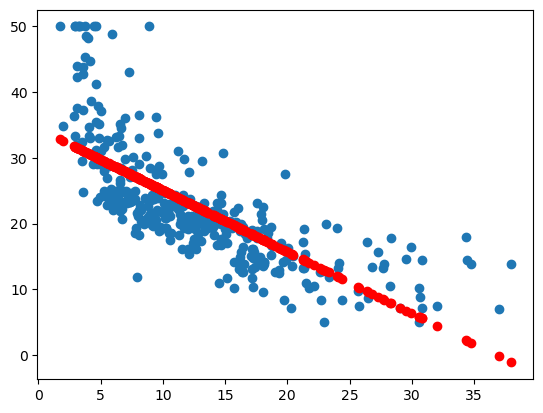

In [113]:
# 확장전 예측값을 살펴보자.
model = LinearRegression()
model.fit(X_train[['LSTAT']], y_train)
pre = model.predict(X_train[['LSTAT']])

# 시각화를 통해서 모델의 예측을 살펴보자
# 산점도 -> 데이터가 얼마나 흩뿌려져 있는지 / 데이터가 진행하는 방향 파악가능(양/음 상관관계)
plt.scatter(X_train['LSTAT'], y_train) # 데이터의 분포를 확인하기 위한 산점도
plt.scatter(X_train['LSTAT'], pre, color='red') # 예측값을 확인하기 위한 산점도
plt.show()

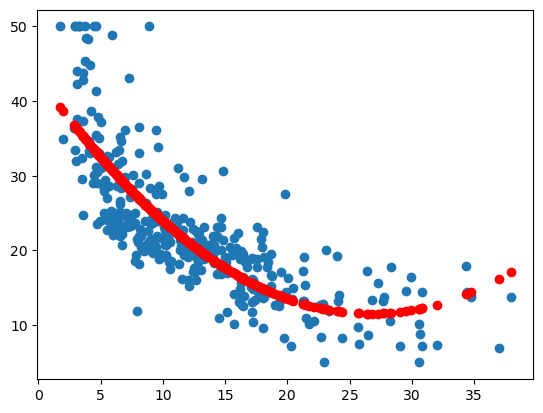

In [114]:
# 확장후 예측값을 살펴보자.(특성 확장 적용)
X_train_copy['LSTAT x LSTAT'] = X_train['LSTAT'] * X_train['LSTAT']
model = LinearRegression()
model.fit(X_train_copy[['LSTAT', 'LSTAT x LSTAT']], y_train)
pre = model.predict(X_train_copy[['LSTAT', 'LSTAT x LSTAT']])

# 시각화를 통해서 모델의 예측을 살펴보자
# 산점도 -> 데이터가 얼마나 흩뿌려져 있는지 / 데이터가 진행하는 방향 파악가능(양/음 상관관계)
plt.scatter(X_train['LSTAT'], y_train) # 데이터의 분포를 확인하기 위한 산점도
plt.scatter(X_train['LSTAT'], pre, color='red') # 예측값을 확인하기 위한 산점도
plt.show()
# 차원이 추가 된것이므로 다차원 구조로 공간이 변화 -> 곡선처럼 보이지만 직선이다
# 특성 확장을 적용하면 기존의 왼쪽 상단의 데이터도 예측을 함 -> 성능이 개선된다.

In [ ]:
# valueError가 뜨는 경우
# X_train_copy / X_test_copy 각각 .columns 찍어보기
# 더 추가된 컬럼이 있다면 해당 컬럼 drop함수로 삭제해주기

In [58]:
X_train_copy.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'LSTAT x LSTAT'],
      dtype='object')

In [59]:
X_test_copy.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'LSTAT X LSTAT', 'LSTAT x LSTAT'],
      dtype='object')

In [60]:
set(X_test_copy) - set(X_train_copy) 

{'LSTAT X LSTAT'}

In [61]:
X_test_copy.drop('LSTAT X LSTAT', axis = 1, inplace = True)

In [115]:
linear_model = LinearRegression()
linear_model.fit(X_train_copy, y_train) # 모델 학습 진행
X_test_copy['LSTAT x LSTAT'] = X_test['LSTAT'] * X_test['LSTAT']
linear_model.score(X_test_copy, y_test)

0.7461423167586887

In [ ]:
# 특성 확장 RM 컬럼 진행해보기

In [63]:
# 데이터 오염 방지를 위해서 복사본 만들기
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

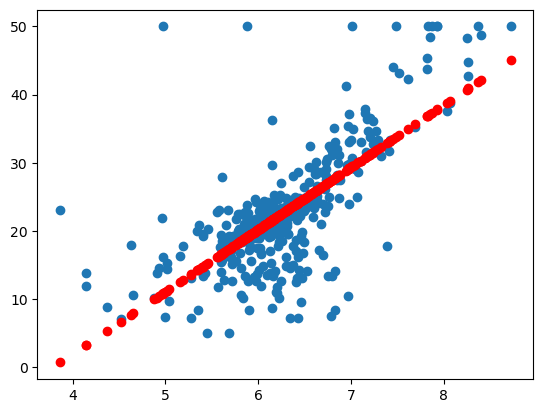

In [116]:
# 확장전 예측값을 살펴보자.
model = LinearRegression()
model.fit(X_train[['RM']], y_train)
pre = model.predict(X_train[['RM']])

# 시각화를 통해서 모델의 예측을 살펴보자
# 산점도 -> 데이터가 얼마나 흩뿌려져 있는지 / 데이터가 진행하는 방향 파악가능(양/음 상관관계)
plt.scatter(X_train['RM'], y_train) # 데이터의 분포를 확인하기 위한 산점도
plt.scatter(X_train['RM'], pre, color='red') # 예측값을 확인하기 위한 산점도
plt.show()

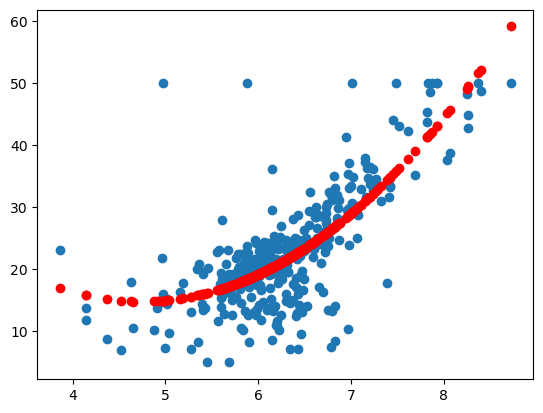

In [73]:
# 확장후 예측값을 살펴보자.(특성 확장 적용)
X_train_copy['RM x RM'] = X_train['RM'] * X_train['RM']
model = LinearRegression()
model.fit(X_train_copy[['RM', 'RM x RM']], y_train)
pre = model.predict(X_train_copy[['RM', 'RM x RM']])

# 시각화를 통해서 모델의 예측을 살펴보자
# 산점도 -> 데이터가 얼마나 흩뿌려져 있는지 / 데이터가 진행하는 방향 파악가능(양/음 상관관계)
plt.scatter(X_train['RM'], y_train) # 데이터의 분포를 확인하기 위한 산점도
plt.scatter(X_train['RM'], pre, color='red') # 예측값을 확인하기 위한 산점도
plt.show()
# 차원이 추가 된것이므로 다차원 구조로 공간이 변화 -> 곡선처럼 보이지만 직선이다
# 특성 확장을 적용하면 기존의 상단 데이터도 예측을 함 -> 성능이 개선된다.

In [74]:
linear_model = LinearRegression()
linear_model.fit(X_train_copy, y_train) # 모델 학습 진행
X_test_copy['RM x RM'] = X_test['RM'] * X_test['RM']
linear_model.score(X_test_copy, y_test)

0.7360833552957742

In [ ]:
# 가설> 특성확장을 하면 성능이 좋아 질 수 있다.

In [75]:
X_train.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [76]:
X_test.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [77]:
# 원본 데이터 복사하기
X_train_copy2 = X_train.copy()
X_test_copy2 = X_test.copy()

In [78]:
# 전체 컬럼은 13개의 컬럼
# 모든 컬럼 확장 진행
for col1 in X_train.columns : # 13번 반복
    for col2 in X_train.columns : # 13번 반복
        X_train_copy2[col1+'x'+col2] = X_train[col1] * X_train[col2]

C:\Users\SMHRD\AppData\Local\Temp\ipykernel_2736\1087063518.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_copy2[col1+'x'+col2] = X_train[col1] * X_train[col2]
C:\Users\SMHRD\AppData\Local\Temp\ipykernel_2736\1087063518.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train_copy2[col1+'x'+col2] = X_train[col1] * X_train[col2]
C:\Users\SMHRD\AppData\Local\Temp\ipykernel_2736\1087063518.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whic

In [79]:
# 경고 제거
import warnings
warnings.filterwarnings('ignore')

In [80]:
# 전체 컬럼은 13개의 컬럼
# 모든 컬럼 확장 진행
for col1 in X_test.columns : # 13번 반복
    for col2 in X_test.columns : # 13번 반복
        X_test_copy2[col1+'x'+col2] = X_test[col1] * X_test[col2]

In [81]:
# 특성 확장된 데이터로 학습을 진행하고 평가를 살펴보자
linear_model = LinearRegression()
linear_model.fit(X_train_copy2, y_train)
linear_model.score(X_test_copy2, y_test)

0.8316359070759262

In [83]:
linear_model.score(X_train_copy2, y_train)

0.9440662127851992

In [84]:
X_train_copy2.shape

(354, 182)

In [85]:
# 과대적합 발생
# 이유? -> 

### 특성 확장 결과
- test 데이터의 R2_Score는 상승했다(성능 개선)
- 하지만 train 데이터의 R2_Score와 비교 해봤을대 과대적합 상태인것이 확인되었다.
- 표면적으로는 성능이 개선된 것처럼 보이나 모델의 신뢰도가 낮은 상태인것이 확인되었다.
- 이유로는 특성확장으로 인한 복잡한 데이터가 선형회귀 모델을 복잡하게 작동하도록 만들었던것이 이유인것으로 판단 된다.

In [86]:
# 규제모델 사용해보기
from sklearn.linear_model import Lasso, Ridge

In [87]:
# 1. Ridge(L2)
# 모델 객체 생성
ridge = Ridge() # 규제강도 기본값 : 1.0

In [88]:
# 반복문을 통해서 규제강도를 변화시켜보고 가중치가 어떻게 변하는지 살펴보자
# 릿지와 라쏘 두가지 모델을 한번에 사용해보자
# 가중치 제어 강도인 알파값을 나열
alpha_list = [0.001, 0.01, 0.1, 1.0, 10, 100, 1000] # 규제강도 값
r_coef_list = [] # 릿지 가중치값 리스트
l_coef_list = [] # 라쏘 가중치값 리스트

for alpha in alpha_list :
    # 모델 생성
    r_model = Ridge(alpha = alpha)
    l_model = Lasso(alpha = alpha)
    # 모델 학습
    r_model.fit(X_train, y_train)
    l_model.fit(X_train, y_train)
    # 각 모델의 가중치 값을 리스트에 저장
    r_coef_list.append(r_model.coef_) # 학습된 릿지모델 가중치를 리스트에 담겠다.
    l_coef_list.append(l_model.coef_) # 학습된 라쏘모델 가중치를 리스트에 담겠다.

In [89]:
# lasso 정규화 결과확인하기
lasso_df = pd.DataFrame(np.array(l_coef_list).T, # 가중치 리스트 전치후 삽입
                       columns = alpha_list, # 컬럼명은 규제 강도값
                        index = X_train.columns) # 인덱스는 각 특성의 이름
lasso_df

,0.001,0.010,0.100,1.000,10.000,100.000,1000.000
CRIM,-0.107572,-0.106355,-0.098789,-0.054771,-0.000000,-0.000000,-0.0
ZN,0.046827,0.047246,0.050633,0.055218,0.031953,0.000000,0.0
INDUS,0.041266,0.028462,-0.022522,-0.000000,-0.000000,-0.000000,-0.0
CHAS,2.701133,2.522381,0.864170,0.000000,0.000000,0.000000,0.0
NOX,-18.672422,-15.694907,-0.000000,-0.000000,-0.000000,-0.000000,-0.0
RM,4.108324,4.111753,3.988604,0.964095,0.000000,0.000000,0.0
AGE,0.015192,0.012695,0.001805,0.042550,0.009507,-0.000000,-0.0
DIS,-1.337365,-1.293213,-1.035704,-0.527343,-0.000000,0.000000,0.0
RAD,0.368349,0.363572,0.345246,0.309174,0.000000,-0.000000,-0.0
TAX,-0.015564,-0.015942,-0.018635,-0.018618,-0.009258,-0.020186,-0.0


In [90]:
# 규제강도 1000 일때 -> 모든 컬럼이 특성제외 -> 데이터 학습을 못한다.

In [91]:
# ridge 정규화 결과확인하기
ridge_df = pd.DataFrame(np.array(r_coef_list).T, # 가중치 리스트 전치후 삽입
                       columns = alpha_list, # 컬럼명은 규제 강도값
                        index = X_train.columns) # 인덱스는 각 특성의 이름
ridge_df

,0.001,0.010,0.100,1.000,10.000,100.000,1000.000
CRIM,-0.107701,-0.107648,-0.107157,-0.104610,-0.102281,-0.098325,-0.081260
ZN,0.046782,0.046800,0.046969,0.047986,0.051020,0.058819,0.063070
INDUS,0.042614,0.041946,0.035816,0.003485,-0.031238,-0.045846,-0.036959
CHAS,2.720672,2.717804,2.690651,2.501251,1.710614,0.440938,0.064524
NOX,-18.986043,-18.832413,-17.422642,-9.964533,-1.891310,-0.205152,-0.013546
RM,4.108102,4.109534,4.122302,4.169096,3.870501,2.060589,0.431161
AGE,0.015452,0.015301,0.013915,0.006808,0.002854,0.022118,0.052970
DIS,-1.342030,-1.339884,-1.320192,-1.216235,-1.103467,-0.981309,-0.449524
RAD,0.368852,0.368597,0.366269,0.354840,0.355630,0.398390,0.333373
TAX,-0.015524,-0.015542,-0.015710,-0.016645,-0.018332,-0.020805,-0.019422
